In [11]:
import pydicom
from pydicom.pixels import iter_pixels

import matplotlib.pyplot as plt

import cv2

import sqlite3

import pandas as pd

import numpy as np

import os

from pathlib import Path

from tqdm import tqdm

In [4]:
base_dir = Path(r"D:\Mitosis WSI CCMCT")

In [5]:
# Creating Training Data Directory
training_data = os.path.join(base_dir, "training_data")
os.makedirs(training_data, exist_ok=True)

# Creating meta_data Directory to store all the tables in the Database
meta_data = os.path.join(base_dir, "meta_data")
os.makedirs(meta_data, exist_ok=True)

In [6]:
# Database path
db_path = r"D:\Mitosis WSI CCMCT\training_data\MITOS_WSI_CCMCT_ODAEL_train_dcm.sqlite"

# Connecting to the data base
conn = sqlite3.connect(db_path)

# Retrieving all the tables from the data base
query = "SELECT name FROM sqlite_master WHERE type='table';"
tables_list = pd.read_sql_query(query, conn)

# Storing all the tables in meta_data directory for easy access
for table_name in tables_list['name']:

    df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    file_path = os.path.join(meta_data, f"{table_name}.csv")
    df.to_csv(file_path, index=False)

conn.close()

In [7]:
df_annots = pd.read_csv(base_dir / "meta_data" / "Annotations.csv")
df_coords = pd.read_csv(base_dir / "meta_data" / "Annotations_coordinates.csv")

master_df = pd.merge(df_annots, df_coords, on='uid')

master_df = master_df[master_df['deleted'] != 1]

In [12]:
def process_dicom_image(path,index=0,dcm=None):

    '''
    Parameters: 
        path    (Required Param)
        index   (Optional Param) 

    Returns:
        Pixel Data if index in range, else returns None
    '''

    '''
    This function takes a raw 12-bit image pixel data and returns normalized 8-bit pixel data.
    Min-Max Normalization is used to normalize the pixel data.
    '''
    
    if dcm is None:
        dcm = pydicom.dcmread(path)

    pixel_generator = iter_pixels(dcm)

    pixel_data = None
    for i,frame in enumerate(pixel_generator):
        if i == index:
            pixel_data = frame
            break

    if pixel_data is not None:
        if pixel_data.max() > 255:
            pixel_data = ((pixel_data - pixel_data.min()) / (pixel_data.max() - pixel_data.min())) * 255
    else:
        print("No data found.")

    return pixel_data
    
    
def get_patch_coordinates(path,index=0):

    '''
    Parameters: 
        path       (Required Param)
        index      (Optional Param) 

    Returns:
        List of Coordinates
    '''

    '''
    This function returns global coordinates of the patch/tile.
    '''

    dcm = pydicom.dcmread(path)

    slide_width = dcm.TotalPixelMatrixColumns
    slide_height = dcm.TotalPixelMatrixRows

    tile_width  = int(dcm.Columns) 
    tile_height = int(dcm.Rows)

    patch_width = slide_width // tile_width

    start_x = (index % patch_width) * tile_width
    start_y = (index // patch_width) * tile_height

    end_x = start_x + tile_width
    end_y = start_y + tile_height

    return [start_x,start_y,end_x,end_y]
    

def get_patch_cell_data(path,index=0):

    '''
    Parameters: 
        path       (Required Param)
        index      (Optional Param) 

    Returns:
        Data Frame
    '''

    '''
    This function returns data/information of all the cells (of all types) which are present in the patch/tile.
    '''

    start_x,start_y,end_x,end_y = get_patch_coordinates(path,index)

    cells_data_in_tile = master_df[
    (master_df['coordinateX'] >= start_x) & (master_df['coordinateX'] < end_x) &
    (master_df['coordinateY'] >= start_y) & (master_df['coordinateY'] < end_y) 
    ]

    return cells_data_in_tile

    
# tile_height = int(dcm.Rows)
# tile_width  = int(dcm.Columns)

# local_x  = coord_x % tile_width
# local_y = coord_y % tile_height

# temp_x = local_x - (patch_size // 2)
# temp_y = local_y - (patch_size // 2)

# local_x = local_x - temp_x
# local_y = local_y - temp_y

# cv2.circle(new_image_data,(local_x, local_y), 20, color, 2)
    
def show_dicom_image(path=None,pixel_data=None,index=None,annot=False):

    '''
    Parameters: 
        path    (Required Param)
        index   (Optional Param) 
        annot   (Optional Param)
        
    Returns:
        None
    '''

    '''
    This function displays a single patch/tile in a WSI, by default it will display index=0 patch without annotations.
    You can choose your desired index and you can display the annotated image by flagging 'annot' parameter to 'True'.
    Note: It doesn't annotate pixel data.
    '''

    if path is None and pixel_data is None:
        print("No data Provided.")
        return

    if path is not None:

        if index == None:
            index = 0
        
        pixel_data = process_dicom_image(path,index)

        if pixel_data is None:
            print("Index Out Of Bounds or No Data, Cannot Display")
            return
    
        new_image_data = pixel_data.copy()
    
        if annot:
        
            cells_data_in_tile = get_patch_cell_data(path,index)
            
            # start_x, start_y, end_x, end_y are global coordinates of the patch/tile.
            start_x, start_y, end_x, end_y = get_patch_coordinates(path, index)
        
            for _, cell in cells_data_in_tile.iterrows():
                
                # local_x and local_y are local coordinates of the center of the cell.
                # cell['coordinateX'] and cell['coordinateY'] are global coordinates of the center of the cell.
                local_x = int(cell['coordinateX'] - start_x)
                local_y = int(cell['coordinateY'] - start_y)
    
                # OpenCV (cv2) uses the BGR (Blue, Green, Red) color order by default.
                # Red - Malignant cell, Green - Mitotic Figure, Blue - Other
                if cell['agreedClass'] == 3: 
                    color = (0,0,255)
                elif cell['agreedClass'] == 2:
                    color = (0, 255, 0)
                else:
                    color = (255,0,0)
                    
                cv2.circle(new_image_data,(local_x, local_y), 20, color, 2)

    else:
        new_image_data = pixel_data

    plt.figure(figsize=(8,8))
    plt.imshow(new_image_data)
    plt.title(f"Tile Index: {index}")
    plt.axis('off')
    plt.show()

def extract_patch(path, coord_x, coord_y,patch_size=64,dcm=None):

    if dcm is None:
        dcm = pydicom.dcmread(path)
    
    slide_width = dcm.TotalPixelMatrixColumns
    slide_height = dcm.TotalPixelMatrixRows

    tile_height = int(dcm.Rows)
    tile_width  = int(dcm.Columns)
    
    # coord_x and coord_y are global coordinates of the centre of the cell.
    if coord_x >= slide_width or coord_y >= slide_height or coord_x < 0 or coord_y < 0:
        return None

    patches_per_row = slide_width // tile_width
    
    tile_col = coord_x // tile_width
    tile_row = coord_y // tile_height
    tile_index = tile_row * patches_per_row + tile_col

    pixel_data = process_dicom_image(path,index=tile_index)
    if pixel_data is None:
        return None

    # local_x and local_y are local coordinates of the center of the cell.
    local_x  = coord_x % tile_width
    local_y = coord_y % tile_height
    
    # We are trying to make a patch from local coordinate of the center of the cell
    # by stretching center of the cell coordinate on all four directions.
    half_patch = patch_size // 2
    start_x = local_x - half_patch
    start_y = local_y - half_patch
    end_x = local_x + half_patch
    end_y = local_y + half_patch

    # Pad if near edges
    pad_left = max(0, -start_x)
    pad_top = max(0, -start_y)
    pad_right = max(0, -(tile_width -  end_x))
    pad_bottom = max(0, -(tile_height - end_y))

    # Making sure that starts and ends to be within tile
    start_x = max(0, start_x)
    start_y = max(0, start_y)
    end_x = min(tile_width, end_x)
    end_y = min(tile_height, end_y)

    patch = pixel_data[start_y:end_y, start_x:end_x]

    # Apply padding if needed (with zeros/black)
    if pad_left or pad_top or pad_right or pad_bottom:
        patch = np.pad(patch, ((pad_top, pad_bottom), (pad_left, pad_right), (0, 0)), mode='constant', constant_values=0)

    return patch

In [9]:
# Creating 'mitotic' and 'non_mitotic' directory in base directory to segregate mitotic and non-mitotic
# cell pictures for the purpose of training.
(base_dir / 'mitotic').mkdir(exist_ok=True)
(base_dir / 'non_mitotic').mkdir(exist_ok=True)

  0%|                                                                                           | 0/21 [00:00<?, ?it/s]C:\Users\user\.conda\envs\gpu_env\Lib\site-packages\pydicom\pixels\decoders\base.py:302: UserWarning: The (0028,0004) 'Photometric Interpretation' value is 'RGB' however the encoded image's codestream contains a JFIF APP marker which indicates it should be 'YBR_FULL_422'
  warn_and_log(


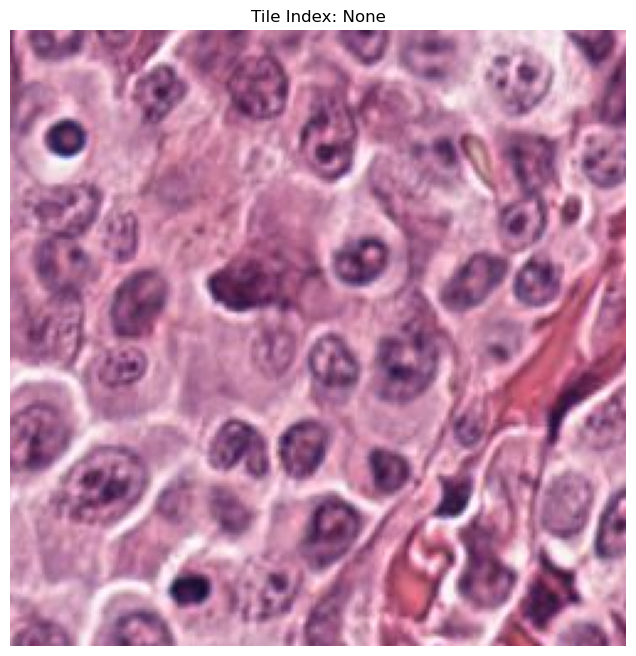

  0%|                                                                                           | 0/21 [02:03<?, ?it/s]


In [10]:
df_slides = pd.read_csv(base_dir / "meta_data" / "Slides.csv")

slide_to_path = {}
for _,row in df_slides.iterrows():
    slide_number = row['uid']
    file_name = row['filename']
    slide_to_path[slide_number] = base_dir / "training_data" / file_name
    
# Since Annotations.csv and Annotations_coordinates.csv are merged based on "uid" in master_df dataframe, 
# note that both tables have "slide" as common column name. So when both tables are merged slide will be named as 
# "slide_x" and "slide_y" respectively. So you can use "slide_x" or "slide_y" as you wish.
grouped = master_df.groupby('slide_x')

for slide_id, group in tqdm(grouped):
    
    dcm_path = slide_to_path.get(slide_id)
    
    if dcm_path is None:
        print(f"Skipping slide {slide_id}: No DICOM path found.")
        continue

    dcm = pydicom.dcmread(dcm_path)
        
    for _, row in group.iterrows():
        
        patch = extract_patch(dcm_path, row['coordinateX'], row['coordinateY'],dcm=dcm)
        
        if patch is None:
            continue

        if row['agreedClass'] == 2:
            output_path = os.path.join(base_dir / 'mitotic', f"{row['uid']}_{row['agreedClass']}.png")
        else:
            output_path = os.path.join(base_dir / 'non_mitotic', f"{row['uid']}_{row['agreedClass']}.png")
    
        cv2.imwrite(output_path, cv2.cvtColor(patch.astype(np.uint8), cv2.COLOR_RGB2BGR))